In [1]:
import sys
import os
import numpy as np

# -----------------------------
# Pattern Storage System
# -----------------------------
class PatternManager:
    def __init__(self):
        # dictionary: label (string) -> feature vector (numpy array)
        self.data = {}

    def add_pattern(self, label, features):
        """
        Store pattern with label and feature vector.
        - label: string
        - features: list or numpy array
        """
        self.data[label] = np.array(features)

    def get_patterns(self):
        """Return all stored patterns."""
        return self.data


# -----------------------------
# Feature Operations
# -----------------------------
class FeatureOperations:

    @staticmethod
    def euclidean_distance(a, b):
        return np.sqrt(np.sum((a - b) ** 2))

    @staticmethod
    def manhattan_distance(a, b):
        return np.sum(np.abs(a - b))

    @staticmethod
    def cosine_similarity(a, b):
        return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# -----------------------------
# Basic Classifier (Nearest Neighbor)
# -----------------------------
class PatternClassifier:

    def __init__(self, pattern_manager):
        self.pm = pattern_manager

    def classify(self, input_features):
        """
        Classify input pattern using nearest neighbor (Euclidean distance).
        """
        input_features = np.array(input_features)

        best_label = None
        best_distance = float("inf")

        for label, features in self.pm.get_patterns().items():
            dist = FeatureOperations.euclidean_distance(input_features, features)

            if dist < best_distance:
                best_distance = dist
                best_label = label

        return best_label, best_distance


# -----------------------------
# Example Usage
# -----------------------------
if __name__ == "__main__":

    # List used to hold input samples (list data structure)
    sample_features = [
        [1.0, 1.1, 0.9],
        [0.2, 0.3, 0.25],
        [0.8, 0.75, 0.78]
    ]

    labels = ["circle", "square", "triangle"]  # string labels

    # Create pattern manager
    pm = PatternManager()

    # Store patterns in dictionary using numpy arrays
    for label, features in zip(labels, sample_features):
        pm.add_pattern(label, features)

    print("Stored Patterns:")
    for label, vec in pm.get_patterns().items():
        print(f"{label} -> {vec}")

    # -----------------------------
    # Compare two patterns
    # -----------------------------
    print("\nPattern Comparison:")
    p1 = pm.get_patterns()["circle"]
    p2 = pm.get_patterns()["square"]

    dist = FeatureOperations.euclidean_distance(p1, p2)
    sim = FeatureOperations.cosine_similarity(p1, p2)

    print("Euclidean Distance:", dist)
    print("Cosine Similarity:", sim)

    # -----------------------------
    # Classification
    # -----------------------------
    classifier = PatternClassifier(pm)

    test_pattern = [0.85, 0.80, 0.82]

    predicted_label, distance = classifier.classify(test_pattern)

    print("\nClassification Result:")
    print("Input:", test_pattern)
    print("Predicted Label:", predicted_label)
    print("Distance:", distance)


Stored Patterns:
circle -> [1.  1.1 0.9]
square -> [0.2  0.3  0.25]
triangle -> [0.8  0.75 0.78]

Pattern Comparison:
Euclidean Distance: 1.304798835069989
Cosine Similarity: 0.9902118361842986

Classification Result:
Input: [0.85, 0.8, 0.82]
Predicted Label: triangle
Distance: 0.08124038404635955


In [2]:
import numpy as np

# ---------------------------------------------------
# 1. Pattern Database Class
# ---------------------------------------------------
class PatternDatabase:
    def __init__(self):
        # Dictionary: label (string) -> feature vector (numpy array)
        self.patterns = {}

    def add_pattern(self, label, features):
        """Add a new pattern to database"""
        self.patterns[label] = np.array(features)

    def get_patterns(self):
        """Return all stored patterns"""
        return self.patterns


# ---------------------------------------------------
# 2. Feature Operations Class
# ---------------------------------------------------
class FeatureOps:

    @staticmethod
    def euclidean(a, b):
        return np.sqrt(np.sum((a - b) ** 2))

    @staticmethod
    def manhattan(a, b):
        return np.sum(np.abs(a - b))

    @staticmethod
    def cosine(a, b):
        return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# ---------------------------------------------------
# 3. Pattern Classifier (Nearest Neighbor)
# ---------------------------------------------------
class PatternClassifier:

    def __init__(self, database):
        self.db = database

    def classify(self, input_vector):
        """Classify input pattern using nearest neighbor"""
        input_vector = np.array(input_vector)

        best_label = None
        best_distance = float("inf")

        print("\n--- Classification Process ---")
        for label, vec in self.db.get_patterns().items():
            dist = FeatureOps.euclidean(input_vector, vec)
            print(f"Distance from {label}: {dist:.4f}")

            if dist < best_distance:
                best_distance = dist
                best_label = label

        return best_label, best_distance


# ---------------------------------------------------
# 4. MAIN PROGRAM (Examples)
# ---------------------------------------------------
if __name__ == "__main__":

    # Create database
    db = PatternDatabase()

    # ------------------------------------------------
    # Store multiple patterns (training data)
    # ------------------------------------------------
    db.add_pattern("circle",   [1.0, 1.1, 0.9])
    db.add_pattern("square",   [0.2, 0.3, 0.25])
    db.add_pattern("triangle", [0.8, 0.75, 0.78])
    db.add_pattern("star",     [0.6, 0.2, 0.9])

    print("=== Stored Patterns ===")
    for label, vec in db.get_patterns().items():
        print(f"{label:10} -> {vec}")

    # ------------------------------------------------
    # Pattern Comparison Example
    # ------------------------------------------------
    print("\n=== Pattern Comparison (circle vs square) ===")

    circle = db.get_patterns()["circle"]
    square = db.get_patterns()["square"]

    eu_dist = FeatureOps.euclidean(circle, square)
    man_dist = FeatureOps.manhattan(circle, square)
    cos_sim = FeatureOps.cosine(circle, square)

    print(f"Euclidean Distance : {eu_dist:.4f}")
    print(f"Manhattan Distance : {man_dist:.4f}")
    print(f"Cosine Similarity  : {cos_sim:.4f}")

    # ------------------------------------------------
    # Classification Examples
    # ------------------------------------------------
    classifier = PatternClassifier(db)

    test_samples = [
        [0.85, 0.80, 0.82],   # likely triangle
        [0.15, 0.25, 0.20],   # likely square
        [0.95, 1.05, 1.00],   # likely circle
        [0.55, 0.30, 0.85]    # likely star
    ]

    print("\n=== Classification Results ===")

    for i, sample in enumerate(test_samples):
        print(f"\nTest Sample {i+1}: {sample}")

        label, dist = classifier.classify(sample)

        print(f"Predicted Class : {label}")
        print(f"Best Distance   : {dist:.4f}")

=== Stored Patterns ===
circle     -> [1.  1.1 0.9]
square     -> [0.2  0.3  0.25]
triangle   -> [0.8  0.75 0.78]
star       -> [0.6 0.2 0.9]

=== Pattern Comparison (circle vs square) ===
Euclidean Distance : 1.3048
Manhattan Distance : 2.2500
Cosine Similarity  : 0.9902

=== Classification Results ===

Test Sample 1: [0.85, 0.8, 0.82]

--- Classification Process ---
Distance from circle: 0.3448
Distance from square: 0.9987
Distance from triangle: 0.0812
Distance from star: 0.6549
Predicted Class : triangle
Best Distance   : 0.0812

Test Sample 2: [0.15, 0.25, 0.2]

--- Classification Process ---
Distance from circle: 1.3910
Distance from square: 0.0866
Distance from triangle: 1.0044
Distance from star: 0.8337
Predicted Class : square
Best Distance   : 0.0866

Test Sample 3: [0.95, 1.05, 1.0]

--- Classification Process ---
Distance from circle: 0.1225
Distance from square: 1.2990
Distance from triangle: 0.4011
Distance from star: 0.9247
Predicted Class : circle
Best Distance   : 0.12

=== STORED PATTERNS ===
circle     -> [1.  1.1 0.9]
square     -> [0.2  0.3  0.25]
triangle   -> [0.8  0.75 0.78]
star       -> [0.6 0.2 0.9]

=== PATTERN COMPARISON (circle vs square) ===

FORMULAS USED:
Euclidean: sqrt(sum((Ai - Bi)^2))
Manhattan: sum(|Ai - Bi|)
Cosine: (A·B) / (|A||B|)

RESULTS:
Euclidean Distance : 1.3048
Manhattan Distance : 2.2500
Cosine Similarity  : 0.9902

=== CLASSIFICATION RESULTS ===

Test Sample 1: [0.85, 0.8, 0.82]

--- Classification Steps ---
Distance from circle: 0.3448
Distance from square: 0.9987
Distance from triangle: 0.0812
Distance from star: 0.6549
Predicted Label : triangle
Best Distance   : 0.0812

Test Sample 2: [0.15, 0.25, 0.2]

--- Classification Steps ---
Distance from circle: 1.3910
Distance from square: 0.0866
Distance from triangle: 1.0044
Distance from star: 0.8337
Predicted Label : square
Best Distance   : 0.0866

Test Sample 3: [0.95, 1.05, 1.0]

--- Classification Steps ---
Distance from circle: 0.1225
Distance from square: 1.2990


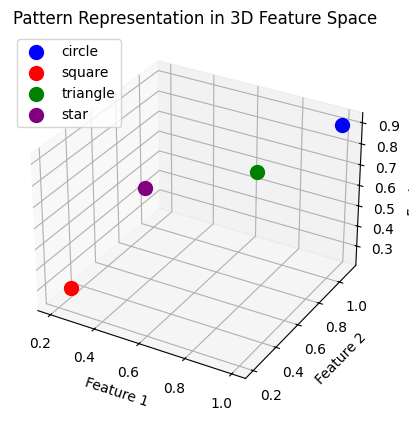

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ---------------------------------------------------
# 1. PATTERN DATABASE
# ---------------------------------------------------
class PatternDatabase:
    def __init__(self):
        self.data = {}

    def add_pattern(self, label, features):
        self.data[label] = np.array(features)

    def get_patterns(self):
        return self.data


# ---------------------------------------------------
# 2. FEATURE OPERATIONS (WITH FORMULAS)
# ---------------------------------------------------
class FeatureOps:

    # Euclidean Distance:
    # d = sqrt(sum((Ai - Bi)^2))
    @staticmethod
    def euclidean(a, b):
        return np.sqrt(np.sum((a - b) ** 2))

    # Manhattan Distance:
    # d = sum(|Ai - Bi|)
    @staticmethod
    def manhattan(a, b):
        return np.sum(np.abs(a - b))

    # Cosine Similarity:
    # cos(θ) = (A · B) / (|A| |B|)
    @staticmethod
    def cosine(a, b):
        return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))


# ---------------------------------------------------
# 3. CLASSIFIER (NEAREST NEIGHBOR)
# ---------------------------------------------------
class Classifier:
    def __init__(self, db):
        self.db = db

    def classify(self, input_vector):
        input_vector = np.array(input_vector)

        best_label = None
        best_distance = float("inf")

        print("\n--- Classification Steps ---")

        for label, vec in self.db.get_patterns().items():
            dist = FeatureOps.euclidean(input_vector, vec)
            print(f"Distance from {label}: {dist:.4f}")

            if dist < best_distance:
                best_distance = dist
                best_label = label

        return best_label, best_distance


# ---------------------------------------------------
# 4. MAIN PROGRAM
# ---------------------------------------------------
if __name__ == "__main__":

    # -------------------------
    # Create database
    # -------------------------
    db = PatternDatabase()

    db.add_pattern("circle",   [1.0, 1.1, 0.9])
    db.add_pattern("square",   [0.2, 0.3, 0.25])
    db.add_pattern("triangle", [0.8, 0.75, 0.78])
    db.add_pattern("star",     [0.6, 0.2, 0.9])

    print("=== STORED PATTERNS ===")
    for label, vec in db.get_patterns().items():
        print(f"{label:10} -> {vec}")

    # -------------------------
    # Pattern Comparison
    # -------------------------
    print("\n=== PATTERN COMPARISON (circle vs square) ===")

    A = db.get_patterns()["circle"]
    B = db.get_patterns()["square"]

    eu = FeatureOps.euclidean(A, B)
    man = FeatureOps.manhattan(A, B)
    cos = FeatureOps.cosine(A, B)

    print("\nFORMULAS USED:")
    print("Euclidean: sqrt(sum((Ai - Bi)^2))")
    print("Manhattan: sum(|Ai - Bi|)")
    print("Cosine: (A·B) / (|A||B|)")

    print("\nRESULTS:")
    print(f"Euclidean Distance : {eu:.4f}")
    print(f"Manhattan Distance : {man:.4f}")
    print(f"Cosine Similarity  : {cos:.4f}")

    # -------------------------
    # Classification
    # -------------------------
    clf = Classifier(db)

    test_samples = [
        [0.85, 0.80, 0.82],
        [0.15, 0.25, 0.20],
        [0.95, 1.05, 1.00],
        [0.55, 0.30, 0.85]
    ]

    print("\n=== CLASSIFICATION RESULTS ===")

    for i, sample in enumerate(test_samples):
        print(f"\nTest Sample {i+1}: {sample}")

        label, dist = clf.classify(sample)

        print(f"Predicted Label : {label}")
        print(f"Best Distance   : {dist:.4f}")

    # -------------------------
    # 3D GRAPH PLOTTING
    # -------------------------
    print("\nGenerating 3D graph...")

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    colors = {
        "circle": "blue",
        "square": "red",
        "triangle": "green",
        "star": "purple"
    }

    # Plot stored patterns
    for label, vec in db.get_patterns().items():
        ax.scatter(vec[0], vec[1], vec[2],
                   color=colors[label],
                   s=100,
                   label=label)

    # Labels
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_zlabel("Feature 3")
    ax.set_title("Pattern Representation in 3D Feature Space")

    ax.legend()

    plt.show()